# Collaborative Filtering
learning from past org–exercise interactions.
## We are using ratings datset for this phase

#### Feature for collaborative filtering
We used the ORG × EXID interaction matrix with ExerciseResults as the main signal, instead of ExerciseRating.

#### Why
ExerciseResults is a clear, measurable outcome of how the organisation performed in an exercise. ExerciseRating looks like a derived or subjective score, 
and we even found strange cases where the result was 0 but the rating was high or low. This makes it hard to understand or trust. By using ExerciseResults, the model is based on more reliable and explainable data.

## Step 1 — Load the splitted datasets
- **What we did:** Loaded the divided datasets (**training**, **validation**, and **test**).  
- **Why use all 3 splitted datasets:**  
  - Training data is used to learn the model.  
  - Validation data helps us tune hyperparameters like number of factors or learning rate.  
  - Test data checks the final model on completely unseen examples.  
  - This avoids data leakage and gives a fair evaluation.


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
    
train_df = pd.read_csv("ratings_train_full.csv")
val_df   = pd.read_csv("ratings_validation_full.csv")
test_df  = pd.read_csv("ratings_test_full.csv")

print(train_df.head(10))


   ORGID  EXID  ExerciseResults  ExerciseRating
0      3    16               22               5
1     24    15                0               2
2     17    13                9               2
3     32     2               10               2
4      3    20                9               2
5     33     3               24               5
6     29    14               19               3
7     33    21               19               3
8     37    19                9               3
9     21    22               18               4


## Step 2 — Choose the Feature + Check Correlation

**What we did:**  
We compared **ExerciseResults** and **ExerciseRating** by calculating their correlation and plotting a scatter plot.

**Why:**  
- To check if the two features are related.  
- We found they were strongly correlated overall (around **0.8**), which proves that ExcerciseRating must be derived from the ExcerciseResult  
- **ExerciseRating** is a clear feature to use for collaborative filtering.

Correlation between ExerciseResults and ExerciseRating: 0.8448815652764291


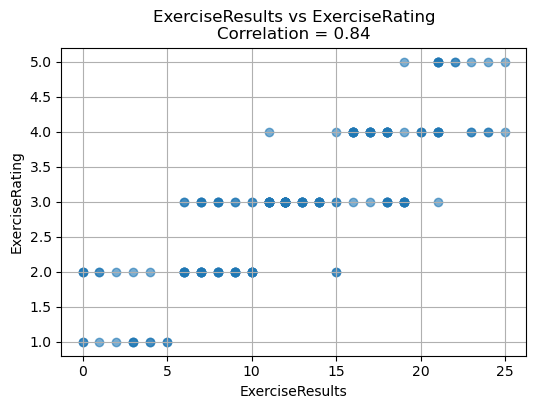

In [26]:
import matplotlib.pyplot as plt

# Calculate correlation
correlation = train_df["ExerciseResults"].corr(train_df["ExerciseRating"], method="pearson")
print("Correlation between ExerciseResults and ExerciseRating:", correlation)

# Scatter plot
plt.figure(figsize=(6,4))
plt.scatter(train_df["ExerciseResults"], train_df["ExerciseRating"], alpha=0.6)
plt.title(f"ExerciseResults vs ExerciseRating\nCorrelation = {correlation:.2f}")
plt.xlabel("ExerciseResults")
plt.ylabel("ExerciseRating")
plt.grid(True)
plt.show()

## Step 3 — Encode Users(Orgs) and Exercises
- **What we did:** Gave every organisation (ORGID) and exercise (EXID) a numeric index, using only the training data.  
- **Why:**  
  - The matrix factorisation algorithm needs numeric indices.  
  - Encoding only from training data prevents information leakage.  


In [27]:
# Build encoders from TRAIN ONLY
u2ix = {u:i for i,u in enumerate(sorted(train_df["ORGID"].unique()))}
i2ix = {x:j for j,x in enumerate(sorted(train_df["EXID"].unique()))}
ix2u = {i:u for u,i in u2ix.items()}
ix2i = {j:x for x,j in i2ix.items()}

def map_indices(df):
    out = df.copy()
    out["u_idx"] = out["ORGID"].map(u2ix)
    out["i_idx"] = out["EXID"].map(i2ix)
    out["rating"] = out["ExerciseRating"].astype(np.float32)   # use result_scaled
    return out

train_m = map_indices(train_df)
val_m   = map_indices(val_df)
test_m  = map_indices(test_df)
train_m.head(), val_m.head(), test_m.head()

(   ORGID  EXID  ExerciseResults  ExerciseRating  u_idx  i_idx  rating
 0      3    16               22               5      2     15     5.0
 1     24    15                0               2     23     14     2.0
 2     17    13                9               2     16     12     2.0
 3     32     2               10               2     31      1     2.0
 4      3    20                9               2      2     19     2.0,
    ORGID  EXID  ExerciseResults  ExerciseRating  u_idx  i_idx  rating
 0      3    22                5               1      2     21     1.0
 1     37    17               14               3     36     16     3.0
 2     11    13               13               3     10     12     3.0
 3     15    27                7               3     14     26     3.0
 4     29    19               25               5     28     18     5.0,
    ORGID  EXID  ExerciseResults  ExerciseRating  u_idx  i_idx  rating
 0     40    28               12               3     39     27     3.0
 1  

## Step 4 — Build the Interaction Matrix
- **What we did:** Created a **sparse org × exercise matrix** where rows are organisations and columns are exercises, filled with the ratings.  
- **Why:**  
  - FunkSVD learns patterns from this matrix.  
  - Sparse storage is efficient, since most organisation–exercise pairs are empty.  
  - Having separate train, val, and test matrices keeps the process consistent.

**Note**: since we are using numpy version 2 scikit-surpise wont work as it is compiled using numpy version 1
- **So using funk_svd.py as a baisc implemention of this algorithm**

In [28]:
from scipy.sparse import csr_matrix

def df_to_csr(frame, shape):
    f = frame.dropna(subset=["u_idx","i_idx"])
    rows = f["u_idx"].astype(int).to_numpy()
    cols = f["i_idx"].astype(int).to_numpy()
    vals = f["rating"].to_numpy(dtype=np.float32)
    return csr_matrix((vals, (rows, cols)), shape=shape, dtype=np.float32)

n_users = len(u2ix)
n_items = len(i2ix)

R_train = df_to_csr(train_m, (n_users, n_items))
R_val   = df_to_csr(val_m,   (n_users, n_items))
R_test  = df_to_csr(test_m,  (n_users, n_items))
print(R_train)

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 177 stored elements and shape (40, 30)>
  Coords	Values
  (0, 3)	3.0
  (0, 9)	2.0
  (0, 14)	2.0
  (0, 16)	2.0
  (0, 25)	2.0
  (1, 2)	3.0
  (1, 6)	3.0
  (1, 16)	2.0
  (1, 29)	2.0
  (2, 0)	3.0
  (2, 3)	1.0
  (2, 8)	4.0
  (2, 9)	3.0
  (2, 15)	5.0
  (2, 19)	2.0
  (3, 3)	2.0
  (3, 19)	3.0
  (3, 20)	3.0
  (3, 22)	5.0
  (3, 24)	2.0
  (3, 28)	2.0
  (4, 3)	3.0
  (4, 10)	3.0
  (4, 15)	5.0
  (4, 17)	2.0
  :	:
  (34, 26)	2.0
  (35, 15)	4.0
  (35, 16)	4.0
  (35, 17)	3.0
  (36, 6)	4.0
  (36, 13)	4.0
  (36, 15)	4.0
  (36, 18)	3.0
  (36, 20)	3.0
  (37, 3)	2.0
  (37, 14)	3.0
  (37, 19)	4.0
  (37, 26)	2.0
  (38, 5)	2.0
  (38, 7)	3.0
  (38, 12)	4.0
  (38, 16)	3.0
  (38, 17)	3.0
  (38, 20)	3.0
  (38, 25)	4.0
  (39, 1)	3.0
  (39, 3)	2.0
  (39, 19)	3.0
  (39, 20)	3.0
  (39, 29)	2.0


## Step 5 — Train the FunkSVD Model
- **What we did:** Trained a **biased matrix factorisation model** (FunkSVD) with latent factors.  
- **Why:**  
  - **Latent factors** capture hidden skills of organisations and hidden difficulty of exercises.  
  - **Bias terms** correct for global effects, e.g., some organisations perform better on everything, some exercises are always harder.  
  - This combination improves both prediction accuracy and fairness.

In [29]:
from funk_svd import FunkSVD

model = FunkSVD(
    n_factors=64,
    n_epochs=40,
    lr=0.005,
    reg_bias=0.01,
    reg_factors=0.05,
    seed=42,
    clip=(1.0, 5.0),
    verbose=True,
    early_stopping=True,
    patience=3,
    eval_every=1,
)

model.fit(R_train, R_val)


[epoch   1] train RMSE=0.9541 | val RMSE=1.0435
[epoch   2] train RMSE=0.9293 | val RMSE=1.0342
[epoch   3] train RMSE=0.9060 | val RMSE=1.0256
[epoch   4] train RMSE=0.8840 | val RMSE=1.0177
[epoch   5] train RMSE=0.8633 | val RMSE=1.0104
[epoch   6] train RMSE=0.8438 | val RMSE=1.0037
[epoch   7] train RMSE=0.8253 | val RMSE=0.9975
[epoch   8] train RMSE=0.8079 | val RMSE=0.9918
[epoch   9] train RMSE=0.7914 | val RMSE=0.9865
[epoch  10] train RMSE=0.7759 | val RMSE=0.9816
[epoch  11] train RMSE=0.7611 | val RMSE=0.9771
[epoch  12] train RMSE=0.7471 | val RMSE=0.9729
[epoch  13] train RMSE=0.7337 | val RMSE=0.9691
[epoch  14] train RMSE=0.7211 | val RMSE=0.9655
[epoch  15] train RMSE=0.7090 | val RMSE=0.9622
[epoch  16] train RMSE=0.6975 | val RMSE=0.9592
[epoch  17] train RMSE=0.6866 | val RMSE=0.9563
[epoch  18] train RMSE=0.6761 | val RMSE=0.9537
[epoch  19] train RMSE=0.6660 | val RMSE=0.9513
[epoch  20] train RMSE=0.6564 | val RMSE=0.9490
[epoch  21] train RMSE=0.6472 | val RMSE

## Step 6 — Evaluate the Model
- **What we did:** Calculated **RMSE** (root mean square error) and **MAE** (mean absolute error) on the test set, but only for users(orgs) and items(excercises) known in training.  
- **Why:**  
  - These metrics show how close predictions are to the actual results.  
  - Focusing on known users/items gives a fair view of collaborative filtering performance.  

Test RMSE=0.610  MAE=0.454


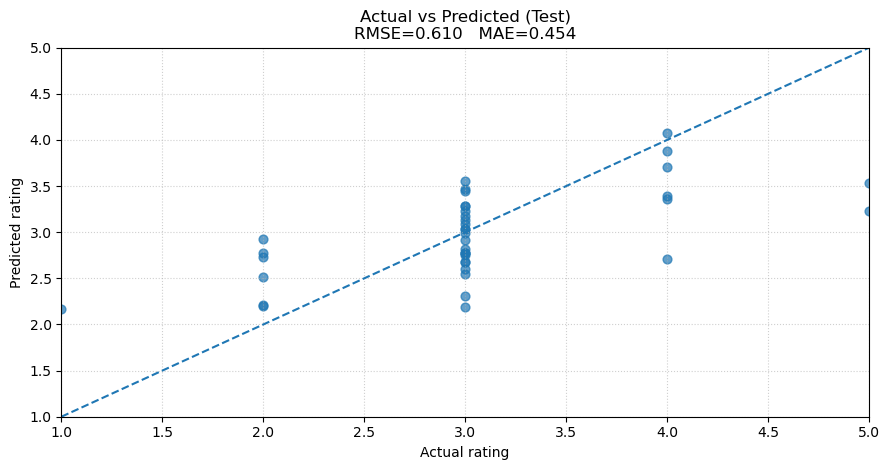

In [30]:
def rmse_mae_on_df(m: FunkSVD, frame: pd.DataFrame):
    se, ae, n = 0.0, 0.0, 0
    for u, i, r in frame[["u_idx","i_idx","rating"]].itertuples(index=False, name=None):
        if pd.isna(u) or pd.isna(i): 
            continue
        p = float(m.predict_one(int(u), int(i)))
        se += (r - p) ** 2
        ae += abs(r - p)
        n += 1
    return (se/n)**0.5, ae/n

rmse, mae = rmse_mae_on_df(model, test_m)
print(f"Test RMSE={rmse:.3f}  MAE={mae:.3f}")


def actual_vs_pred_df(m, frame: pd.DataFrame) -> pd.DataFrame:
    """Build a tidy DF with actual & predicted ratings for known (u,i) in `frame`."""
    rows = []
    for u, i, r in frame[["u_idx","i_idx","rating"]].itertuples(index=False, name=None):
        if pd.isna(u) or pd.isna(i):
            continue  # skip cold-start pairs
        p = float(m.predict_one(int(u), int(i)))
        rows.append((float(r), p))
    return pd.DataFrame(rows, columns=["actual", "pred"])

df_ap = actual_vs_pred_df(model, test_m)

plt.figure(figsize=(9,4.8))

# Left: text-style metrics header (optional, or just print)
plt.subplot(1,1,1)
plt.scatter(df_ap["actual"], df_ap["pred"], alpha=0.7, s=40)

# y = x diagonal (reference)
lims = [1.0, 5.0]
plt.plot(lims, lims, linestyle="--")

plt.xlim(lims); plt.ylim(lims)
plt.xlabel("Actual rating")
plt.ylabel("Predicted rating")
plt.title(f"Actual vs Predicted (Test)\nRMSE={rmse:.3f}   MAE={mae:.3f}")
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()


## Step 7 — Generate Top-N Recommendations
- **What we did:** For each organisation, predicted scores for exercises they haven’t attempted and recommended the **Top-N** highest.  
- **Why:**  
  - This produces actionable recommendations.  
  - Excluding already-seen exercises avoids suggesting repeats.  

In [31]:
import numpy as np
import pandas as pd

# What each org has already seen in TRAIN
seen = train_m.groupby("ORGID")["EXID"].apply(set).to_dict()

u_uniques = np.array(sorted(train_df["ORGID"].unique()))
i_uniques = np.array(sorted(train_df["EXID"].unique()))

def recommend_for_all_orgs(model, R_train, u_uniques, i_uniques, topn=5, exclude_seen=True):
    rows = []
    for u_idx, org_id in enumerate(u_uniques):
        if org_id not in seen:   # skip cold-start users
            continue
        scores = np.asarray(model.predict_for_org(u_idx), dtype=float)
        if exclude_seen:
            for ex in seen[org_id]:
                j = i2ix.get(ex, None)
                if j is not None:
                    scores[j] = -np.inf
        k = min(topn, len(i_uniques))
        top_idx = np.argpartition(-scores, k-1)[:k]
        top_idx = top_idx[np.argsort(-scores[top_idx])]
        for j in top_idx:
            rows.append({"ORGID": int(org_id), "EXID": int(i_uniques[j]), "score": float(scores[j])})
    return pd.DataFrame(rows)

print(recommend_for_all_orgs(model, R_train, u_uniques, i_uniques, topn=5))


     ORGID  EXID     score
0        1     7  3.390368
1        1    16  3.309920
2        1    23  3.235246
3        1    24  2.997736
4        1     9  2.936177
..     ...   ...       ...
195     40     7  3.545105
196     40    23  3.524988
197     40    16  3.498140
198     40    17  3.301501
199     40     3  3.167482

[200 rows x 3 columns]


# Summary
1. Split the dataset for fair training and testing.  
2. Used **ExerciseResults** instead of ExerciseRating for clarity and reliability.  
3. Scaled results to a common 1–5 range.  
4. Encoded organisations and exercises into numeric IDs (train-only).  
5. Built sparse matrices for train, validation, and test.  
6. Trained FunkSVD with latent factors and bias terms.  
7. Evaluated using RMSE and MAE on the test set.  
8. Produced Top-N exercise recommendations for each organisation.  